# BalloonLib — Quick Start  

End-to-end demonstration of the **BalloonLib** PINN library:  
from numerical simulation of haemodynamics to PINN training and evaluation.

**Pipeline**
```
Stimulus → Numerical ODE (balloonmodellib)  →  reference f, m, v, q, BOLD
         → PINN (Multihead)                →  learned f, m, v, q, HRF
         → Evaluation (kge_stat, hrf_description)
         → [Optional] Noisy BOLD training
```

> **GPU recommended.** The library detects CUDA automatically.

## 0  Setup and imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ── BalloonLib (explicit submodule imports — preferred over balloonpinnlib shim)
from balloonlib import balloonmodellib_new as bml  # numerical ODE solver
from balloonlib.model import Multihead
from balloonlib.training import loss
from balloonlib.elbo_training import elbo_train
from balloonlib.data import experimental_stims
from balloonlib.utils import np2tensor, tensor2np, tofit, timeBall
from balloonlib.metrics import kge_stat, hrf_description
from balloonlib.plotting import plot_balloon_fitting, plot_trace, plot_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)
print(f"Using device: {device}")

Using device: cuda


## 1  Stimulus design

We use a block-design stimulus with 10 onsets at 1.75 s TR (166 volumes, ~4.8 min).

In [2]:
# ── fMRI acquisition parameters
TR = 1.75  # Repetition time (s)
n_samples = 166  # number of fMRI volumes
Bold_time = np.arange(0, n_samples * TR, TR)

sti_len = 3  # stimulus block duration (s)
Sti_Onsets = np.array([22, 42, 79, 99, 134, 163, 191, 209, 236, 269]) - 1  # onset times (s)

# ── High-res (0.01 s) impulse used by the PINN
Impulse = torch.zeros(30).repeat(100)  # 30 s at 100 Hz
Impulse[105:205] = 1  # stimulus on from 0.05 s to 1.05 s

# ── Overall stimulus for BOLD convolution
Overall_stims, stim_time = experimental_stims(
    normDataSize=n_samples,
    Sti_Onsets=Sti_Onsets,
    TR=TR,
    block_len=sti_len,
    stmxblck=1,
    Hz=100,
)
stim_time_np = tensor2np(stim_time)
print(f"Stimulus tensor shape: {Impulse.shape}  ({Impulse.shape[0] / 100:.0f} s at 100 Hz)")
print(f"Overall stim shape:    {Overall_stims.shape}")

Stimulus tensor shape: torch.Size([3000])  (30 s at 100 Hz)
Overall stim shape:    torch.Size([29050, 1])


## 2  Numerical Balloon model (reference solution)

`balloonmodellib` solves the Balloon ODE system numerically (scipy).  
These solutions serve as ground-truth overlays when evaluating the PINN.

In [3]:
# ── Neurovascular coupling → f (CBF) and m (CMRO₂)
f_parameters = {"gamma": 1 / 2.46, "kappa": 1 / 1.54}

f_np,m_np, = bml.neurovascular_coupling_fm(
            stimulus=tensor2np(Impulse),
            AmpI_f= 0.2,
            AmpI_m= 0.05,
            params = f_parameters
        )


# ── Balloon core → blood volume (v) and deoxyhaemoglobin (q)
vol_q_parameters = {"tau_MTT": 3.0, "alpha": 0.4, "tau_m": 20}
v_np, q_np = bml.Balloon_odeint(f_np, m_np, params=vol_q_parameters, viscoelastic=True)

# ── BOLD signal
bold_params = {"E_0": 0.32, "V_0": 0.03, "TE": 0.06, "O_o": 40.3, "r_0": 25, "eps": 1.43}
bold_np = bml.BOLD_func(v_np, q_np, params=bold_params, BM="classic")

# ── Convert to tensors
f_t = np2tensor(f_np)
m_t = np2tensor(m_np)
v_t = np2tensor(v_np)
q_t = np2tensor(q_np)
num_balloon_hrf = np2tensor(bold_np)

print(f"f shape: {f_t.shape} | m: {m_t.shape} | v: {v_t.shape} | q: {q_t.shape}")
print(f"Numerical HRF range: [{bold_np.min():.4f}, {bold_np.max():.4f}]")

f shape: torch.Size([3000, 1]) | m: torch.Size([3000, 1]) | v: torch.Size([3000, 1]) | q: torch.Size([3000, 1])
Numerical HRF range: [-0.0006, 0.0063]


## 3  Simulate BOLD signal (no noise)

Convolve the numerical HRF with the experimental stimulus to get a synthetic BOLD signal,  
then subsample it at the fMRI TR.

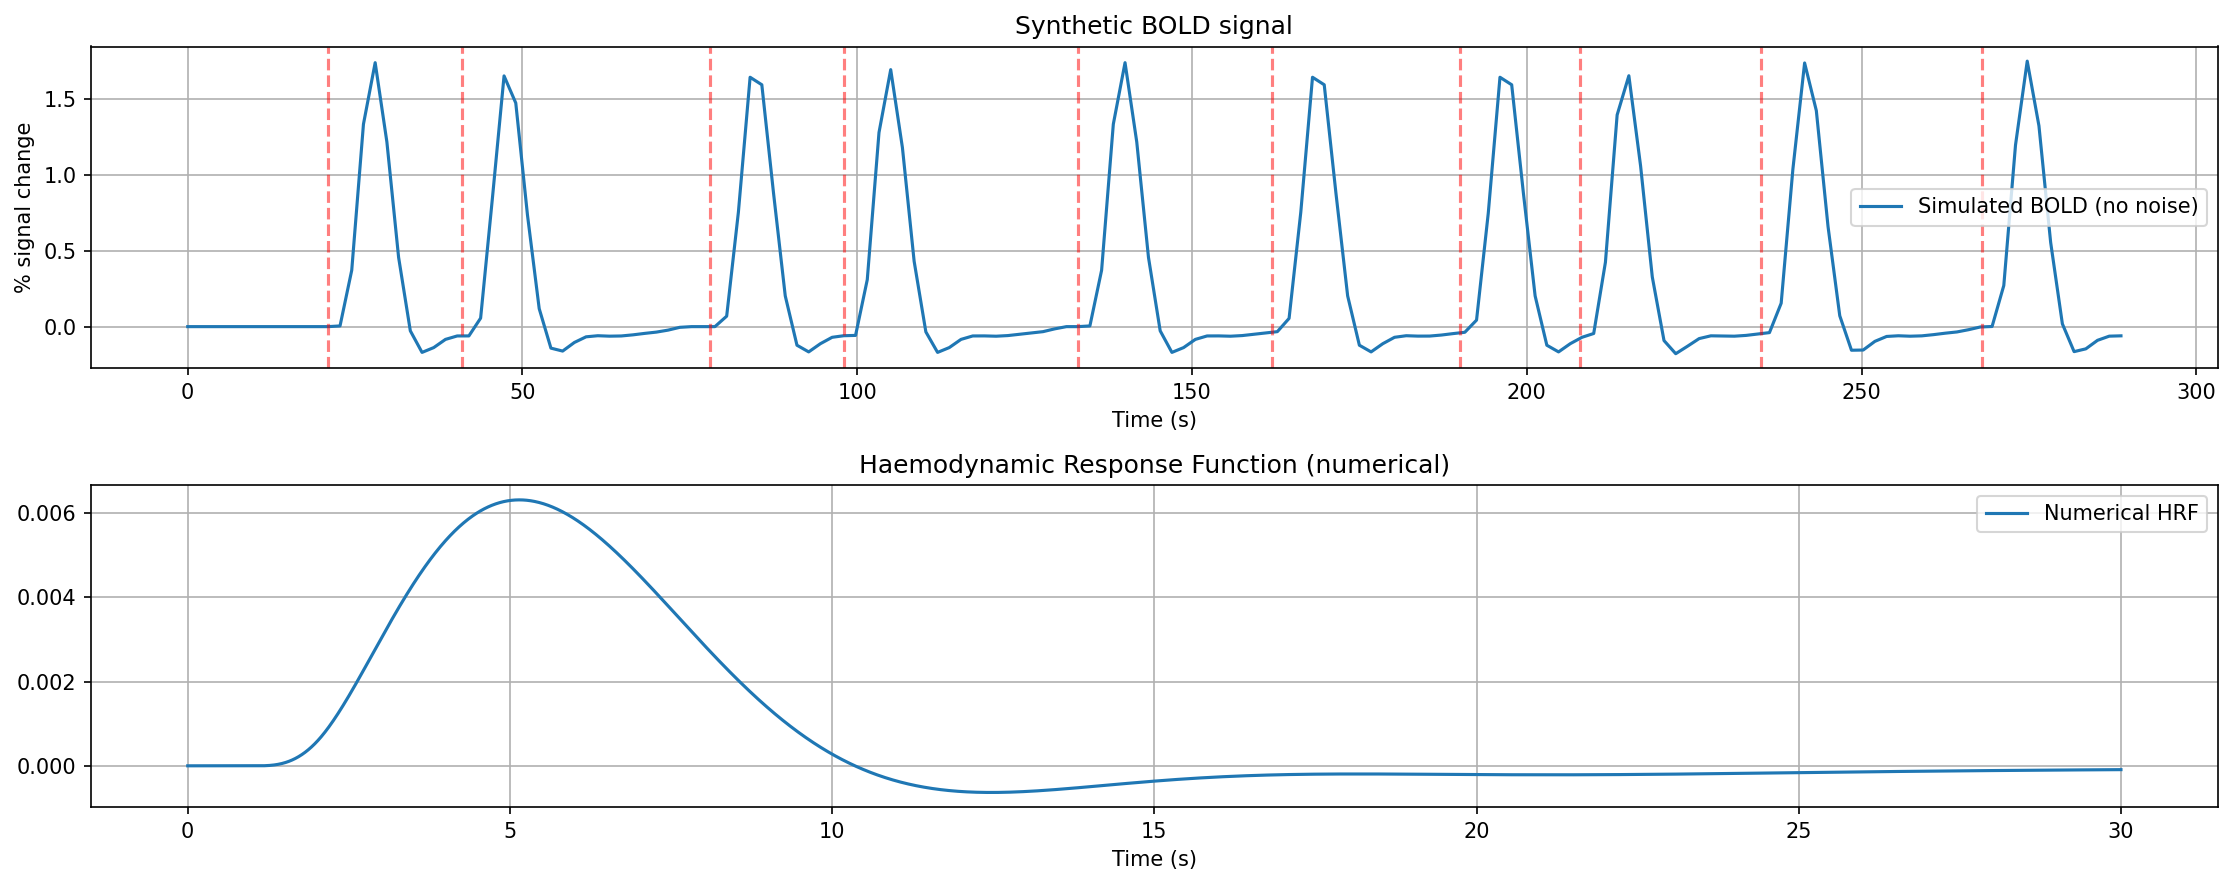

In [4]:
sampling_rate = int(TR * 100)  # samples to skip = TR × Hz

num_bold_test, num_bold_time = tofit(Overall_stims, num_balloon_hrf, n_samples * TR)
sampled_bold_test = tensor2np(num_bold_test[::sampling_rate])

fig, ax = plt.subplots(2, 1, figsize=(15, 6), dpi=150)
ax[0].plot(Bold_time, sampled_bold_test, label="Simulated BOLD (no noise)")
[ax[0].axvline(x=i, color="r", ls="--", alpha=0.5) for i in Sti_Onsets]
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("% signal change")
ax[0].set_title("Synthetic BOLD signal")
ax[0].legend()
ax[0].grid()

t_hrf = np.linspace(0, 30, len(bold_np))
ax[1].plot(t_hrf, bold_np, label="Numerical HRF")
ax[1].set_xlabel("Time (s)")
ax[1].set_title("Haemodynamic Response Function (numerical)")
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

## 4  Configure Balloon_params and data_params

`Balloon_params` — physiological ODE constants passed to `loss()` and `train()`.  
`data_params`   — fMRI data, stimulus metadata, and training settings.

In [5]:
domain = (0, len(Impulse) * 0.01)  # physical time window: [0, 30] s
num_iter = 5000
every = num_iter // 3  # plot progress 3 times during training

learning_rate = 1e-3
percent, step_size = 0.6, 1000  # StepLR: lr × 0.85 every 1000 iters

# ── Initial loss weights  (lists — histories are appended during training)
p = 0.60
w_raw = {
    "ode": [p],  # ODE residual
    "bold": [1 - p],  # data fit
    "ic": [1.0],  # Dirichlet IC  (f=m=v=q=1 at t=0)
    "border": [1.0],  # Cauchy IC     (derivatives=0 at t=0)
    "other":  [1.],   # physics violation penalty (off by default)
}

# ── data_params
data_dict = {
    "TR": TR,
    "Sti_Onsets": Sti_Onsets,
    "Bold_Signal": sampled_bold_test,  # numpy array, shape (n_samples,)
    "errorFn": nn.MSELoss(),
    "stim_length [seg]": sti_len,  # block duration (s)
    "stim_x_block": 1,  # stimuli per block
    "t0": 0,  # BOLD record start (s)
}

# ── Balloon_params  (physiological ODE constants from Stephan 2007 / Buxton 2004)
Balloon_dict = {
    "lambdar_list": [0.2, 0.05],  # [CBF amplitude, CMRO2 amplitude]
    "kappa_list": [1 / 1.54, 1 / 1.54],  # [CBF decay, CMRO2 decay]  (Maith 2022)
    "gamma_list": [1 / 2.46, 1 / 2.46],  # [CBF return, CMRO2 return]
    "tau_m_list": 20,  # viscoelastic time constant (s)
    "tau_MTT_list": 3.0,  # mean transit time (s)
    "alpha": 0.4,  # Grubb's stiffness exponent
    "I": Impulse,  # high-res stimulus tensor
}

print("Balloon_dict keys:", list(Balloon_dict.keys()))
print("data_dict keys:", list(data_dict.keys()))

Balloon_dict keys: ['lambdar_list', 'kappa_list', 'gamma_list', 'tau_m_list', 'tau_MTT_list', 'alpha', 'I']
data_dict keys: ['TR', 'Sti_Onsets', 'Bold_Signal', 'errorFn', 'stim_length [seg]', 'stim_x_block', 't0']


## 5  Build the PINN

`Multihead` simultaneously predicts all four Balloon state variables  
(*f*, *m*, *v*, *q*) from a normalised time input.

In [6]:
# ── Optional: fix random seed for reproducibility
# seed = 42
# torch.manual_seed(seed)
# if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

model = Multihead(
    use_fourier=False,  # set True for Fourier feature encoding
    fourier_mapping_size=9,
    fourier_scale=0.85,
    fourier_learnable=True,
    multi_scale_fourier=False,
    random_weightsMatrix=True,  # use FactorizedLinear (RWF) layers
    impulse=False,  # time-only input
    act=nn.Softmax(dim=1),
    nv_fn=(nn.Softplus(), nn.Softplus()),
    core_fn=(nn.Softplus(), nn.Softplus()),
    dtype=torch.float32,
)
model.init_nn_params()

total_params = sum(p.numel() for p in model.parameters())
print(
    f"PINN ready: {total_params:,} trainable parameters | device: {next(model.parameters()).device}"
)

PINN ready: 165,897 trainable parameters | device: cuda:0


## 6  Train — clean (noise-free) simulation

The `train()` loop:
- Normalises time to zero-mean / unit-std
- Segments the BOLD data into stimulus-locked epochs
- Runs `num_iter` Adam steps with StepLR decay
- Plots progress every `every` iterations

# Prior + posterior (new cell before the optimizer)

In [7]:
from balloonlib import make_ode_prior, BalloonPosterior, elbo_train

base_balloon_params = {
      "I":          Impulse,           # high-res impulse tensor
   }
prior     = make_ode_prior(init_log_std=-1.0, 
                  fixed_params={
                     'epsilon_n' : 0.2,
                     'kappa'     : 1/1.54,
                     'gamma'     : 1/2.46
                  })
posterior = BalloonPosterior(prior)
prior.print_summary()


  BalloonLatentPrior  —  K = 3 parameters
Parameter         Mode (physical)  Std (η-space)
------------------------------------------------
tau_0                      3.0000         0.3679
tau_m                     20.0000         0.3679
alpha                      0.4000         0.3679

Correlation matrix (unconstrained space):
                  tau_0    tau_m    alpha
  tau_0           1.000    0.000    0.000
  tau_m           0.000    1.000    0.000
  alpha           0.000    0.000    1.000

Fixed parameters (not sampled):
  epsilon_n      0.2
  kappa          0.6493506493506493
  gamma          0.4065040650406504



 33%|███▎      | 1665/5000 [00:23<00:45, 72.82it/s]


[1666/5000]  elbo=1.2544e+00  pinn=4.8611e-03  kl=1.2495e+00  β=1.000
  ode=2.668e-03  bold=1.308e-03  ic=2.663e-04  border=3.389e-04
  posterior mode →  tau_0=2.6318  tau_m=19.9878  alpha=0.4031  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


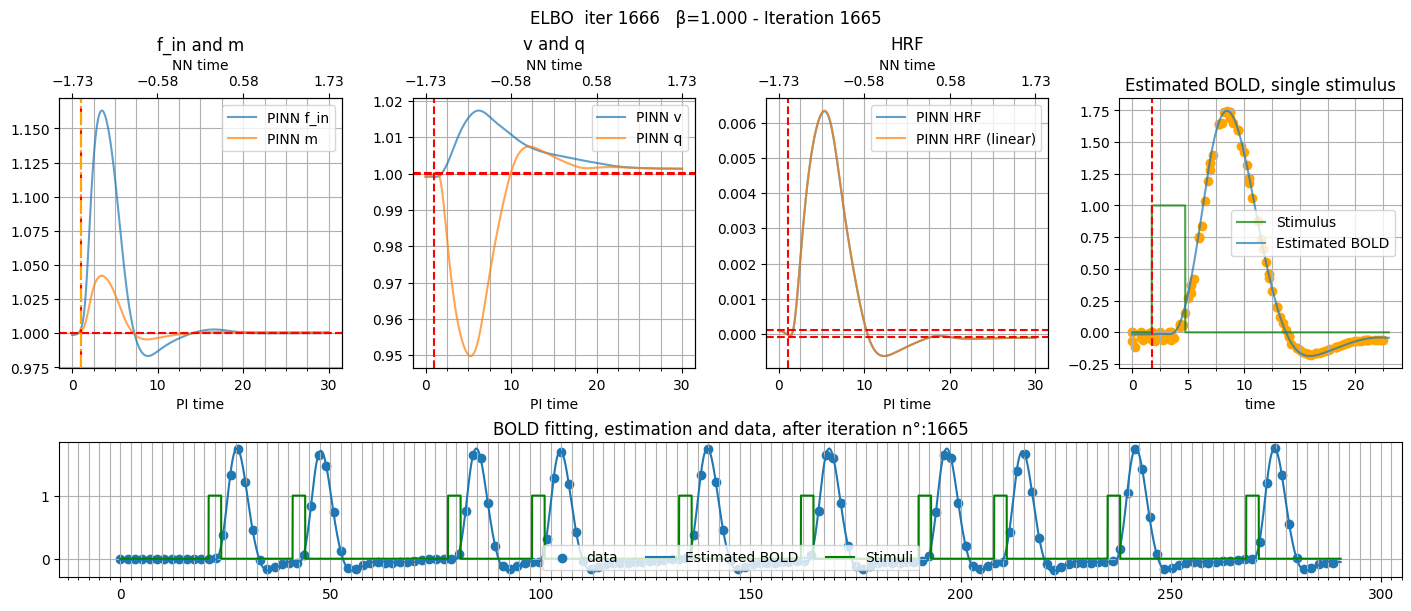

 67%|██████▋   | 3329/5000 [00:46<00:23, 72.24it/s]


[3332/5000]  elbo=9.3788e-01  pinn=3.2538e-03  kl=9.3463e-01  β=1.000
  ode=1.989e-03  bold=3.136e-04  ic=2.286e-04  border=1.207e-04
  posterior mode →  tau_0=2.6518  tau_m=19.8218  alpha=0.4035  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


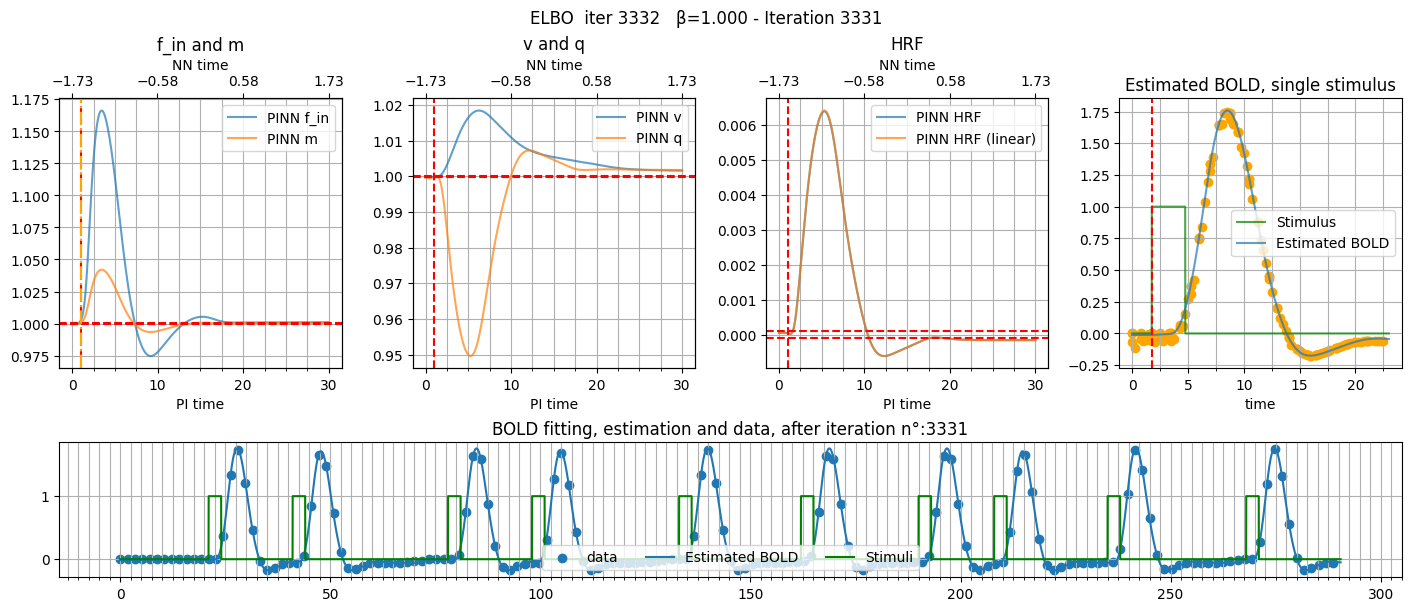

100%|█████████▉| 4992/5000 [01:08<00:00, 75.87it/s]


[4998/5000]  elbo=8.1634e-01  pinn=2.8178e-03  kl=8.1352e-01  β=1.000
  ode=2.078e-03  bold=2.026e-04  ic=1.478e-04  border=8.333e-05
  posterior mode →  tau_0=2.6635  tau_m=19.8048  alpha=0.4037  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


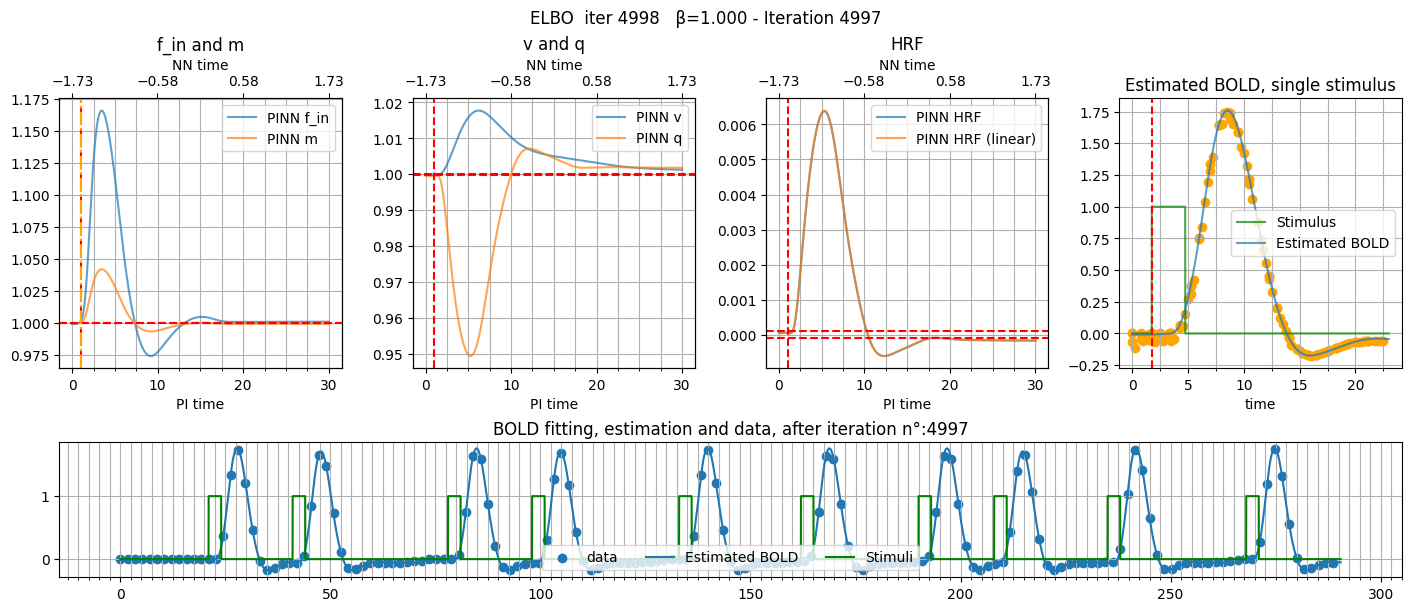

100%|██████████| 5000/5000 [01:09<00:00, 71.90it/s]


In [8]:
# Joint optimizer — PINN weights + posterior (mu_q, L_q)
# optimizer_elbo = torch.optim.Adam(
#       list(model.parameters()) + list(posterior.parameters()),
#       lr=learning_rate,
#   )
optimizer_elbo = torch.optim.Adam([
{'params':model.parameters(), 'lr':learning_rate},
{'params':posterior.parameters(), 'lr':learning_rate/10}
])

scheduler_elbo = optim.lr_scheduler.StepLR(
      optimizer_elbo, step_size=step_size, gamma=percent
  )

loss_trace_elbo = elbo_train(
      model             = model,
      posterior         = posterior,
      base_balloon_params = base_balloon_params,   # mutated in-place
      data_params       = dict(data_dict),         # fresh copy — also mutated
      num_iter          = num_iter,
      beta_max          = 1.0,
      warmup_iters      = 500,
      optimizer         = optimizer_elbo,
      scheduler         = scheduler_elbo,
      loss_weights      = w_raw,
      domain            = domain,
      random            = False,
      every             = every,
  )



## 7  Visualise — state variables + BOLD fit

/home/steren/Documents/PinnLab/BalloonPinn/BalloonLib/.venv/lib/python3.12/site-packages/torch/utils/_device.py:122: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  return func(*args, **kwargs)


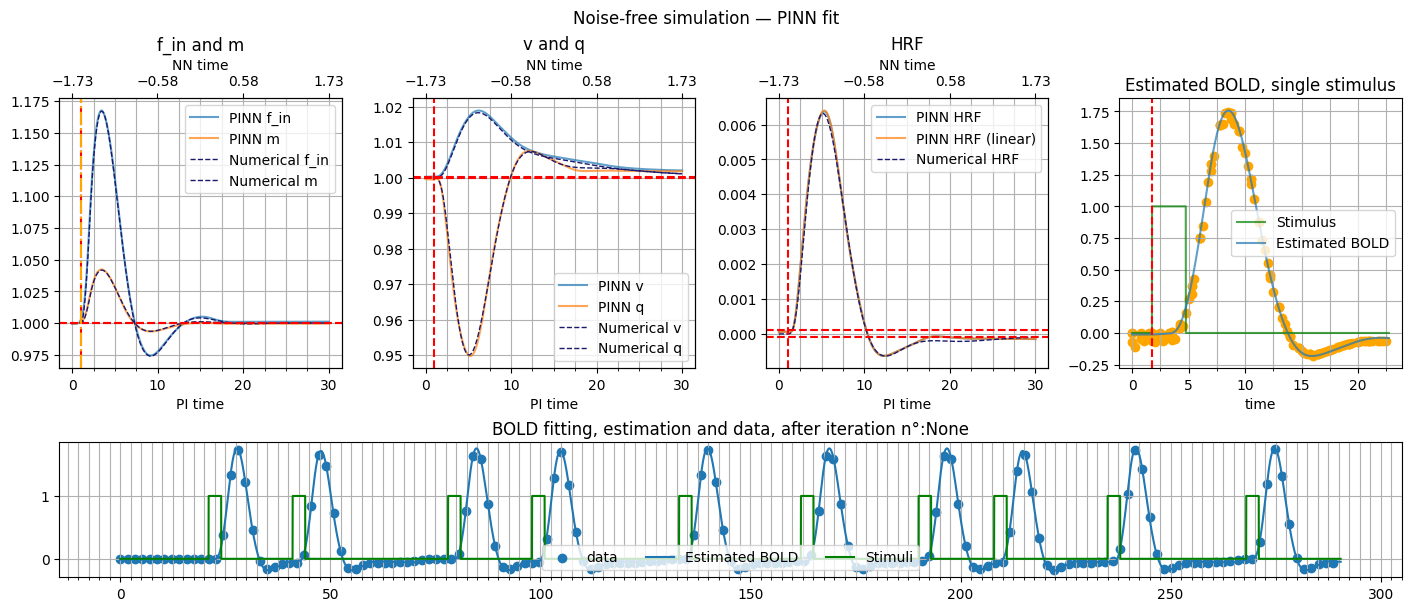

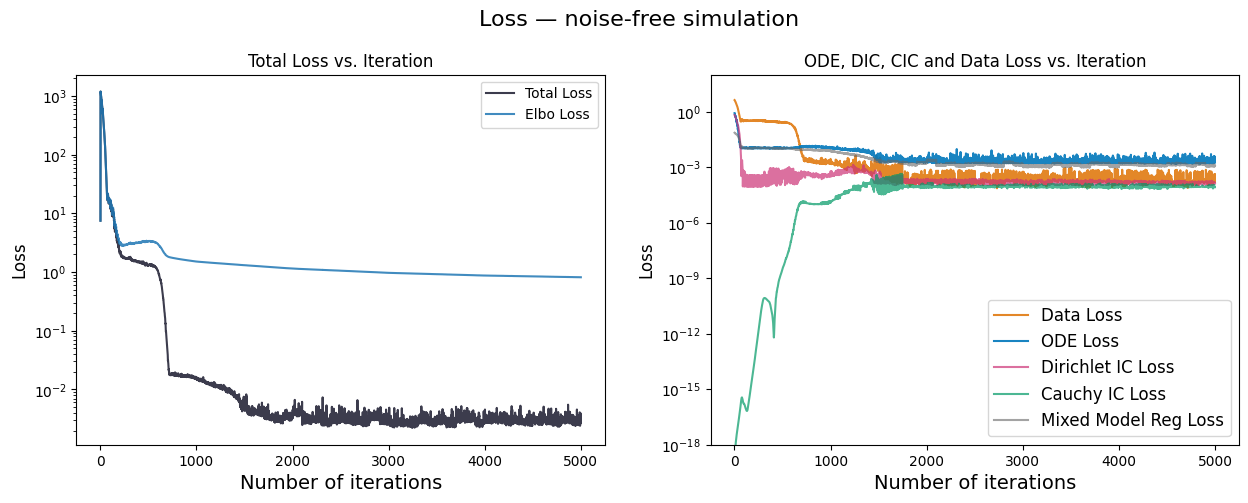

In [9]:
# load the best model checkpoint
best_model_cp = torch.load('./best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])

# Build the normalised time axis that train() used internally
t = torch.arange(0, Impulse.shape[0]) / Impulse.shape[0]
t_nn = ((t - t.mean()) / t.std()).view(-1, 1)

# Single-trial stimulus (needed for show_bold_signal panel)
time_bf_stim = TR
stimulus, stimulus_time = experimental_stims(
    normDataSize=13,
    Sti_Onsets=[time_bf_stim],
    TR=TR,
    block_len=sti_len,
    stmxblck=1,
)

plot_balloon_fitting(
    model=model,
    t_normalized=t_nn,
    domain=domain,
    stimulus=stimulus,
    title="Noise-free simulation — PINN fit",
    numerical_solutions={"f": f_t, "m": m_t, "v": v_t, "q": q_t, "bold": num_balloon_hrf},
    data_params={
        "TR": TR,
        "Sti_Onsets": Sti_Onsets,
        "Bold_Signal": sampled_bold_test,
        "Bold_data_time": num_bold_time[::sampling_rate],
        "stim_length [seg]": sti_len,
        "stimulus": stimulus,
        "stimulus_time": stimulus_time,
        "Overallstim": Overall_stims,
        "Overall_stim_time": stim_time,  # ← correct key name
    },
    first_non_zero_index=torch.argmax(Impulse) - 1,
    show_bold_signal=True,
)

tmp = dict(list(loss_trace_elbo.items())[:5])
tmp['total'] = loss_trace_elbo['pinn_total']
tmp['elbo_total'] = loss_trace_elbo['elbo_total']
plot_trace(tmp , title="Loss — noise-free simulation", step_size=step_size)

{'tau_0': 2.6635148525238037, 'tau_m': 19.804689407348633, 'alpha': 0.40374505519866943}


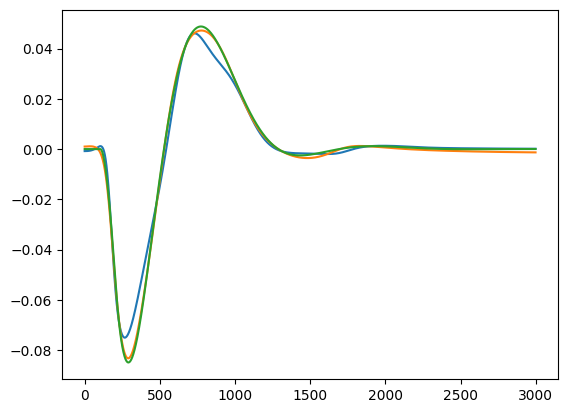

In [10]:
from balloonlib.physics import dfdt

with torch.no_grad():
    physical_mode = {
        name: posterior.prior._transforms[i](posterior.mu_q[i]).item()
        for i, name in enumerate(posterior.prior.param_names)
    }
print(physical_mode)

# Fresh time tensor with grad enabled BEFORE the forward pass
t_nn_grad = t_nn.detach().requires_grad_(True)
t_scale = (t_nn_grad[-1] - t_nn_grad[0]) / (domain[1] - domain[0])
# Forward pass — v and q are now connected to t_nn_grad in the graph
with torch.no_grad():
    pass  # clear any previous model state
_, _ = model(t_nn_grad)

# Now dfdt can differentiate v and q w.r.t. t_nn_grad
dvdt, dqdt = [t_scale*dfdt(signal=i.squeeze(), arg=t_nn_grad) for i in [model.v, model.q]]

# Your expression
result = physical_mode['tau_0'] * (model.v * dqdt - model.q * dvdt)
#plt.plot(3.0*100*((v_np[:-1]*np.diff(q_np))-(q_np[:-1]*np.diff(v_np))))
plt.plot(tensor2np(physical_mode['tau_0']*((model.v * dqdt) - (model.q * dvdt))))
plt.plot(tensor2np(model.v*model.m - model.q*model.f))
plt.plot(((v_np*m_np)-(q_np*f_np)))

In [11]:
posterior = BalloonPosterior(prior)
prior.print_summary()


  BalloonLatentPrior  —  K = 3 parameters
Parameter         Mode (physical)  Std (η-space)
------------------------------------------------
tau_0                      2.6635         0.2619
tau_m                     19.8045         0.2631
alpha                      0.4037         0.2619

Correlation matrix (unconstrained space):
                  tau_0    tau_m    alpha
  tau_0           1.000    0.099    0.028
  tau_m           0.099    1.000   -0.001
  alpha           0.028   -0.001    1.000

Fixed parameters (not sampled):
  epsilon_n      0.2
  kappa          0.6493506493506493
  gamma          0.4065040650406504



In [12]:
print(model.beta)
print(model.Davis_M)

tensor(1.5314, device='cuda:0', grad_fn=<AddBackward0>)
Parameter containing:
tensor(0.0750, device='cuda:0', requires_grad=True)


tensor(0.4037, device='cuda:0')


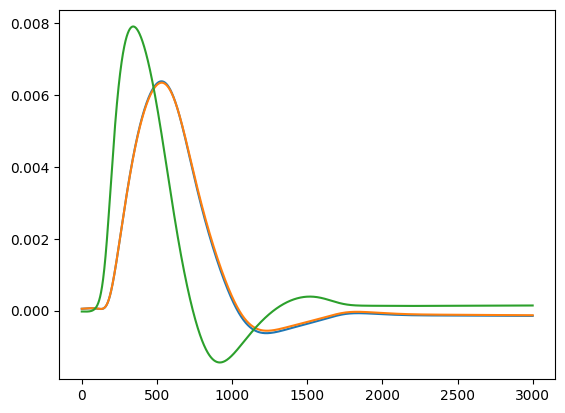

In [13]:
with torch.no_grad():
    idx = posterior.prior.param_names.index("alpha")
    alpha_mean = posterior.prior._transforms[idx](posterior.mu_q[idx])

_,_ = model(t_nn)
plt.plot(model.predictor().detach().cpu().numpy())
plt.plot(model.hDavis(volume=True, params={'M':model.Davis_M, 'beta':model.beta}).detach().cpu().numpy())
plt.plot(model.hDavis(volume=False, params={"alpha": alpha_mean, 'M':model.Davis_M, 'beta':model.beta}).detach().cpu().numpy())
print(alpha_mean)


In [14]:
# plot_weights(
#     w_raw, title="Adaptive weights — noise-free simulation", keys_to_skip=[], step_size=step_size
# )

## 8  Quantitative evaluation

In [15]:
model.eval()
with torch.no_grad():
    _, _ = model(t_nn)
    hrf_pinn = model.predictor()

# Convolve HRF with overall stimulus → BOLD prediction at high resolution
bold_pred, bold_pred_time = tofit(Overall_stims, hrf_pinn, n_samples * TR)

# Subsample to fMRI TR
idx, _ = timeBall(torch.as_tensor(Bold_time), bold_pred_time)
bold_at_TR = tensor2np(bold_pred[idx])

# Kling-Gupta Efficiency (1.0 = perfect)
kge = kge_stat(y_obs=sampled_bold_test, y_sim=bold_at_TR)
print(f"KGE = {kge:.4f}  (1.0 = perfect)")

# HRF shape descriptors
desc = hrf_description(tensor2np(hrf_pinn), max_time=domain[1])
for k, v_d in desc.items():
    print(f"  {k}: {v_d[0]:.4f}")

KGE = 0.9493  (1.0 = perfect)
  HP: 0.0064
  TTP[s]: 5.3000
  FWHM[s]: 4.8100
  TO[s]: 2.0000
  AUC: 0.0307
  MU: -0.0006
  TTU[s]: 12.2300
  TT0[s]: 17.4200


---
## 9  Noise addition (Shan 2014)

We now train the same PINN on a **noisy** simulation to test robustness.  
Noise is added as:  $\hat{TC} = TC + (1 + \sigma) \cdot \epsilon$

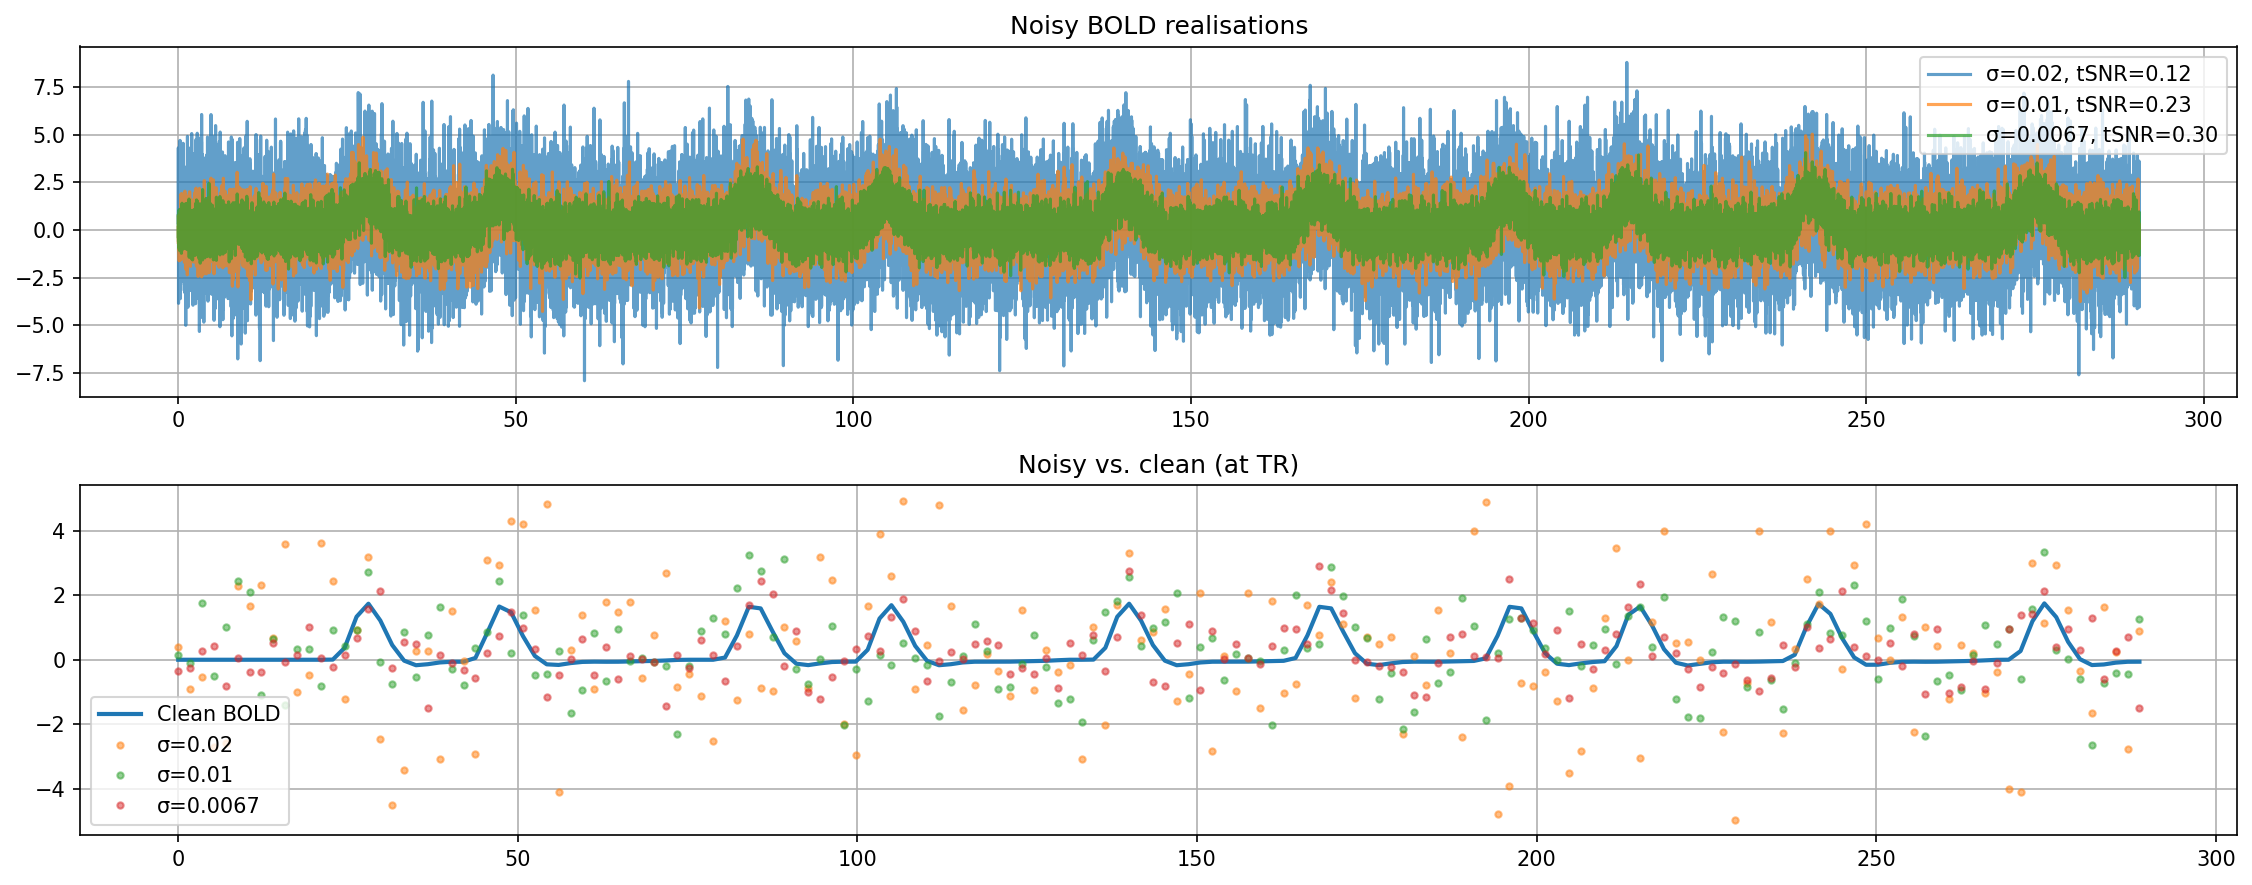

In [16]:
# Generate three noise levels
# fork_rng saves and restores PyTorch's RNG state after the block,
# so this seed does not affect any subsequent random draws in the notebook.
noise_levels = [0.02, 0.01, 0.0067]
with torch.random.fork_rng(enabled=True):
    torch.manual_seed(42)
    noise_list = [torch.randn(1, len(num_bold_test)) * s for s in noise_levels]
noise = torch.cat(noise_list, dim=0)  # shape (3, N)


def adding_noise(TC, noise_tensor):
    n_signals = noise_tensor.shape[0]
    return TC.repeat(n_signals, 1) + 100 * noise_tensor


def tSNR(x):
    ax = int(np.argmax(x.shape))
    return x.mean(axis=ax) / x.std(axis=ax)


tmp = tensor2np(adding_noise(num_bold_test, noise))
tsnr_vals = list(tSNR(tmp))


def norm(x, a):
    return 100 * (x - x.mean(axis=a)) / x.mean(axis=a)


fig, ax = plt.subplots(2, 1, figsize=(15, 6), dpi=150)
labels = [f"σ={s}" for s in noise_levels]
for k, (row, lbl) in enumerate(zip(tmp, labels)):
    ax[0].plot(stim_time_np, row, alpha=0.7, label=f"{lbl}, tSNR={tsnr_vals[k]:.2f}")
ax[0].set_title("Noisy BOLD realisations")
ax[0].legend()
ax[0].grid()

ax[1].plot(Bold_time, sampled_bold_test, label="Clean BOLD", lw=2)
for k, (row, lbl) in enumerate(zip((tmp[:, ::sampling_rate]), labels)):
    ax[1].plot(Bold_time, row, ".", alpha=0.5, label=lbl)
ax[1].set_title("Noisy vs. clean (at TR)")
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

## 10  Train on noisy BOLD (σ = 0.01)

In [17]:
prior     = make_ode_prior(init_log_std=-1.0, 
                  fixed_params={
                     'epsilon_n' : 0.2,
                     'kappa'     : 1/1.54,
                     'gamma'     : 1/2.46
                  })

posterior = BalloonPosterior(prior)
prior.print_summary()


  BalloonLatentPrior  —  K = 3 parameters
Parameter         Mode (physical)  Std (η-space)
------------------------------------------------
tau_0                      3.0000         0.3679
tau_m                     20.0000         0.3679
alpha                      0.4000         0.3679

Correlation matrix (unconstrained space):
                  tau_0    tau_m    alpha
  tau_0           1.000    0.000    0.000
  tau_m           0.000    1.000    0.000
  alpha           0.000    0.000    1.000

Fixed parameters (not sampled):
  epsilon_n      0.2
  kappa          0.6493506493506493
  gamma          0.4065040650406504



 17%|█▋        | 1662/10000 [00:22<01:53, 73.69it/s]


[1666/10000]  elbo=1.9543e+01  pinn=1.7098e+01  kl=2.4452e+00  β=1.000
  ode=1.575e-03  bold=4.589e+00  ic=1.353e-04  border=1.567e-04
  posterior mode →  tau_0=2.9520  tau_m=19.9484  alpha=0.4020  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


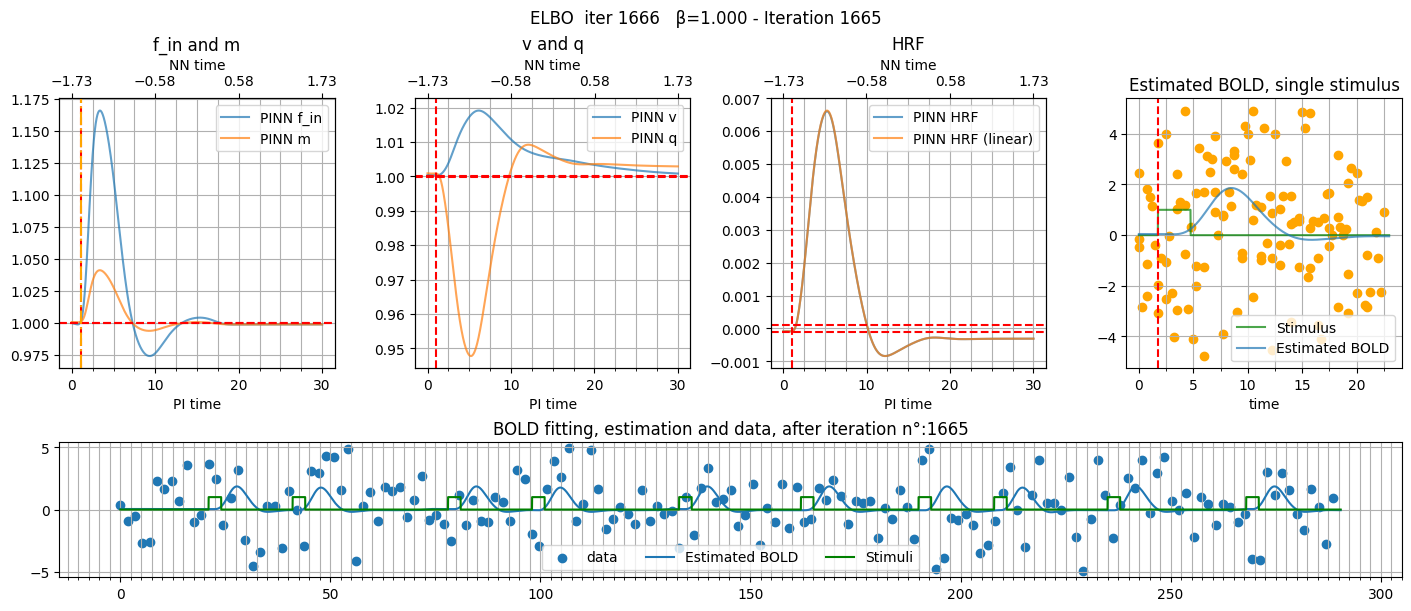

 33%|███▎      | 3326/10000 [00:46<01:34, 70.86it/s]


[3332/10000]  elbo=2.2666e+01  pinn=2.0230e+01  kl=2.4364e+00  β=1.000
  ode=1.838e-03  bold=4.558e+00  ic=1.535e-04  border=8.477e-05
  posterior mode →  tau_0=2.9494  tau_m=19.9476  alpha=0.4022  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


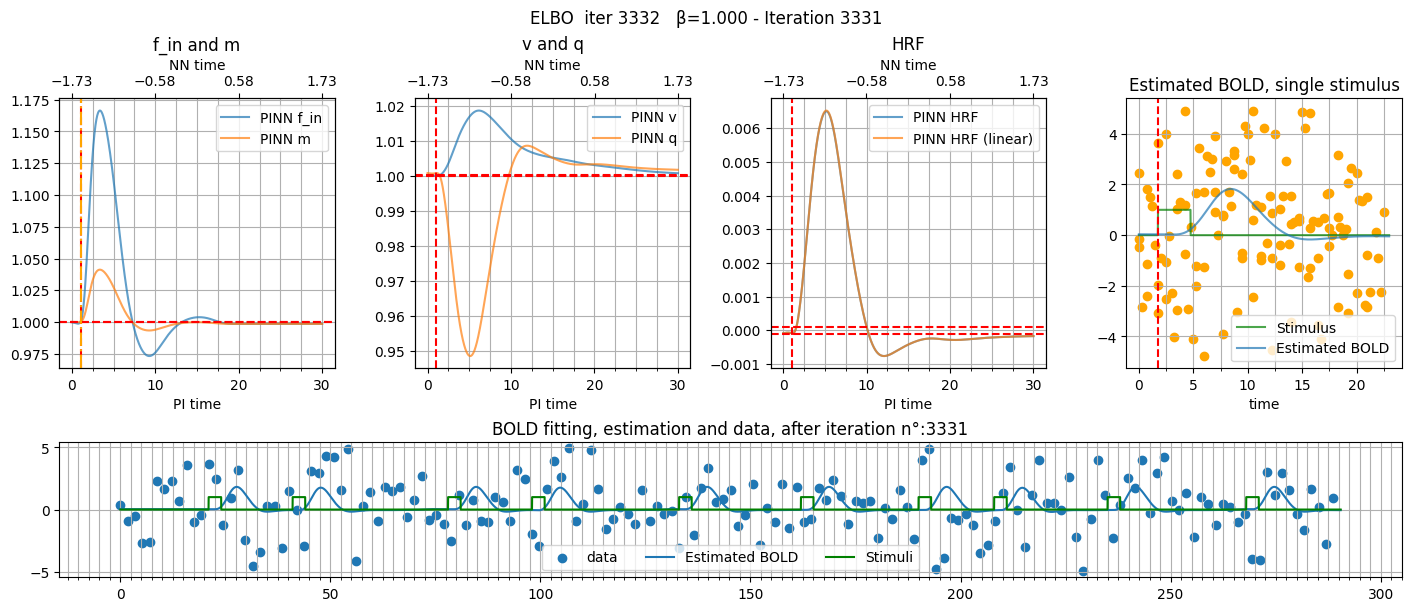

 50%|████▉     | 4995/10000 [01:10<01:08, 73.12it/s]


[4998/10000]  elbo=1.9392e+01  pinn=1.6963e+01  kl=2.4291e+00  β=1.000
  ode=1.622e-03  bold=4.550e+00  ic=1.275e-04  border=8.702e-05
  posterior mode →  tau_0=2.9480  tau_m=19.9479  alpha=0.4024  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


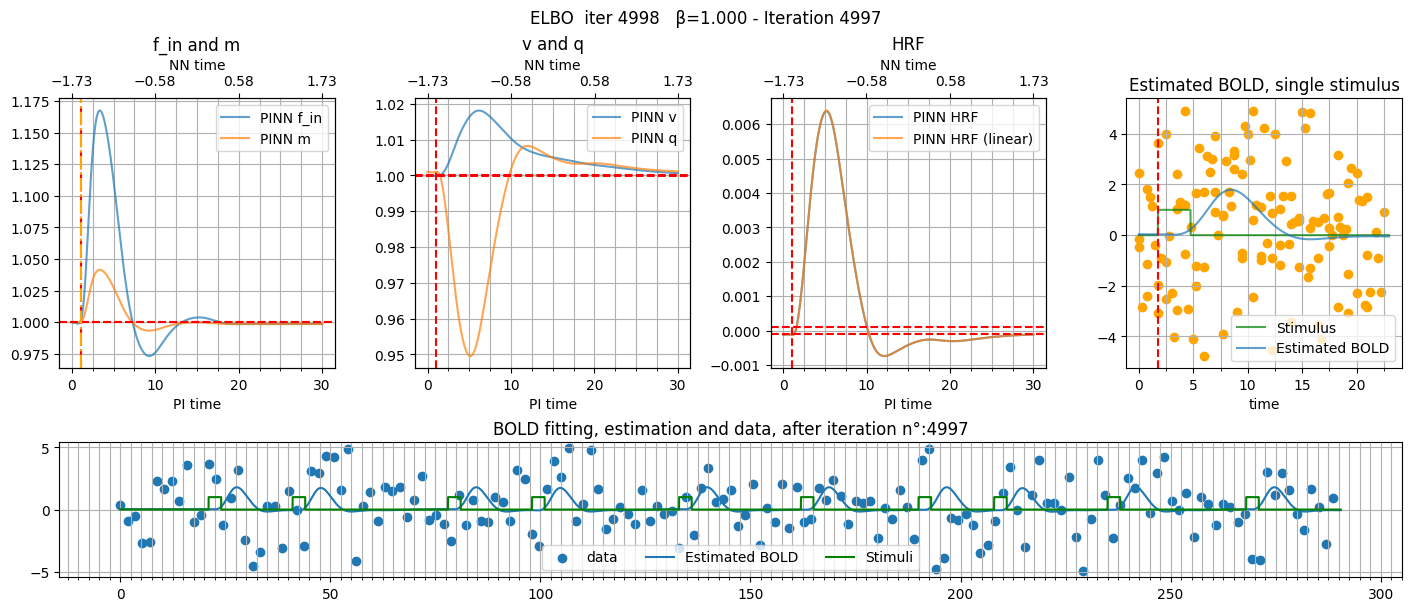

 67%|██████▋   | 6657/10000 [01:33<00:45, 73.05it/s]


[6664/10000]  elbo=2.1878e+01  pinn=1.9453e+01  kl=2.4251e+00  β=1.000
  ode=1.945e-03  bold=4.550e+00  ic=1.507e-04  border=8.091e-05
  posterior mode →  tau_0=2.9479  tau_m=19.9476  alpha=0.4024  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


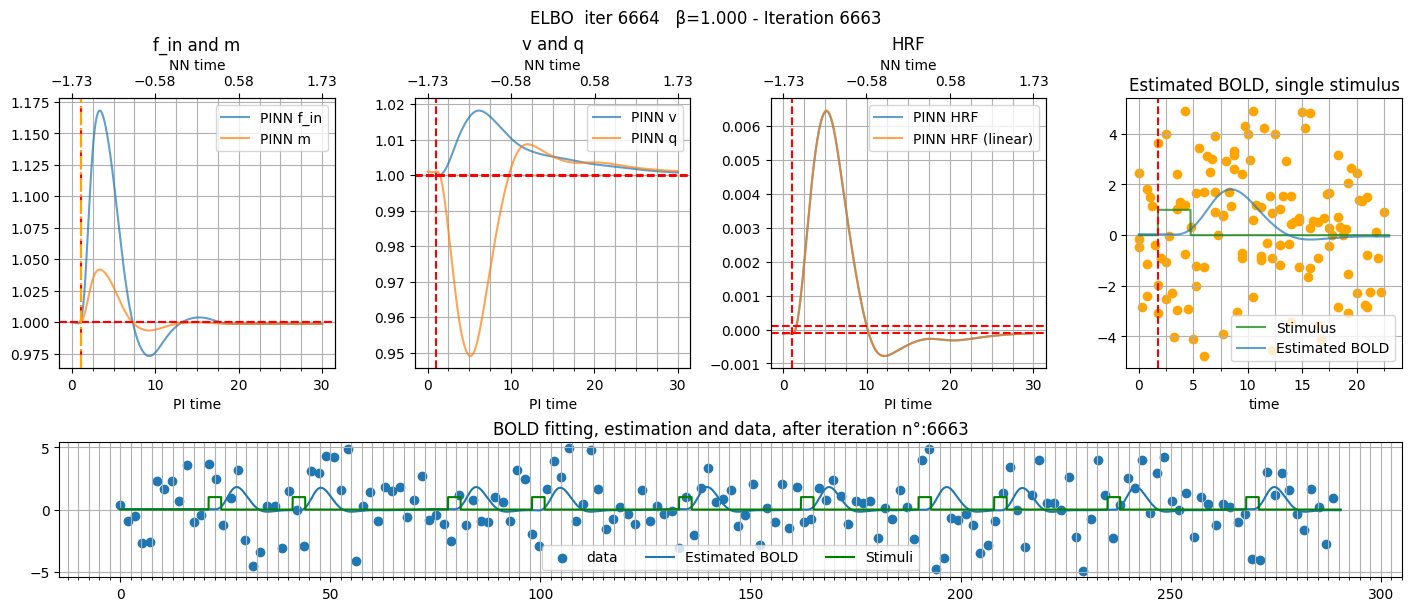

 83%|████████▎ | 8328/10000 [01:57<00:22, 73.17it/s]


[8330/10000]  elbo=2.1773e+01  pinn=1.9350e+01  kl=2.4233e+00  β=1.000
  ode=1.887e-03  bold=4.575e+00  ic=1.149e-04  border=1.197e-04
  posterior mode →  tau_0=2.9476  tau_m=19.9473  alpha=0.4024  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


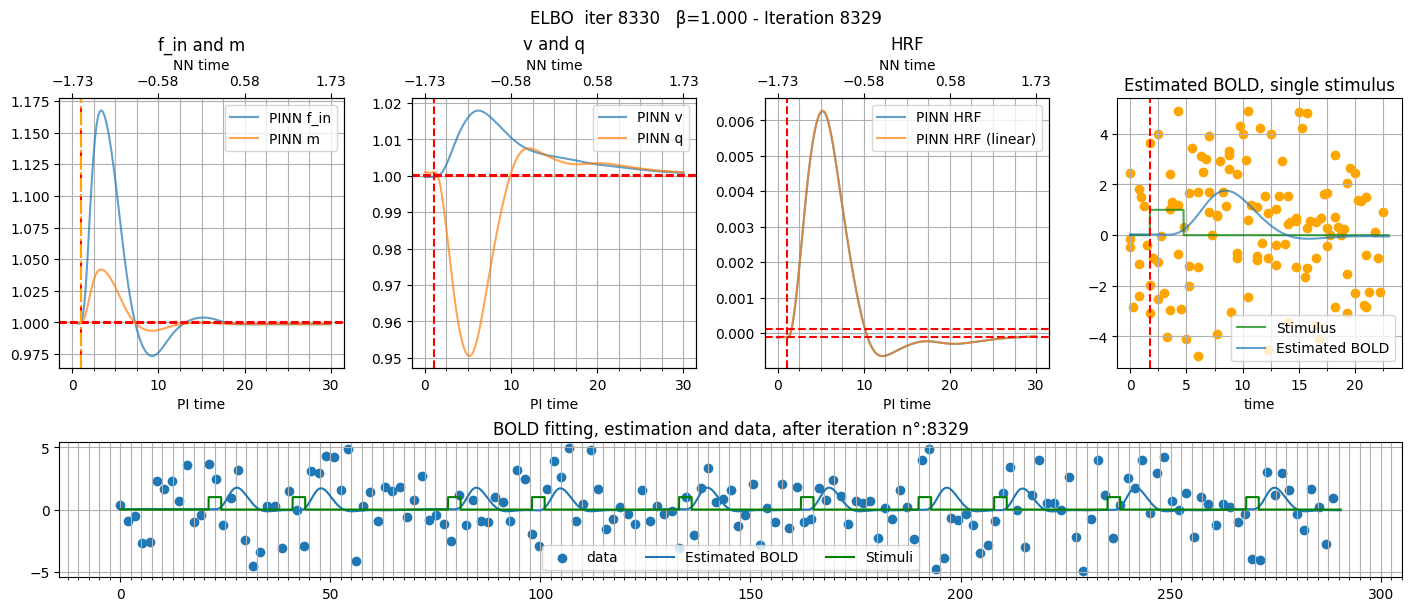

100%|█████████▉| 9992/10000 [02:20<00:00, 68.74it/s]


[9996/10000]  elbo=2.3377e+01  pinn=2.0954e+01  kl=2.4225e+00  β=1.000
  ode=1.996e-03  bold=4.548e+00  ic=1.303e-04  border=1.202e-04
  posterior mode →  tau_0=2.9476  tau_m=19.9473  alpha=0.4024  epsilon_n=0.2000[fixed]  kappa=0.6494[fixed]  gamma=0.4065[fixed]


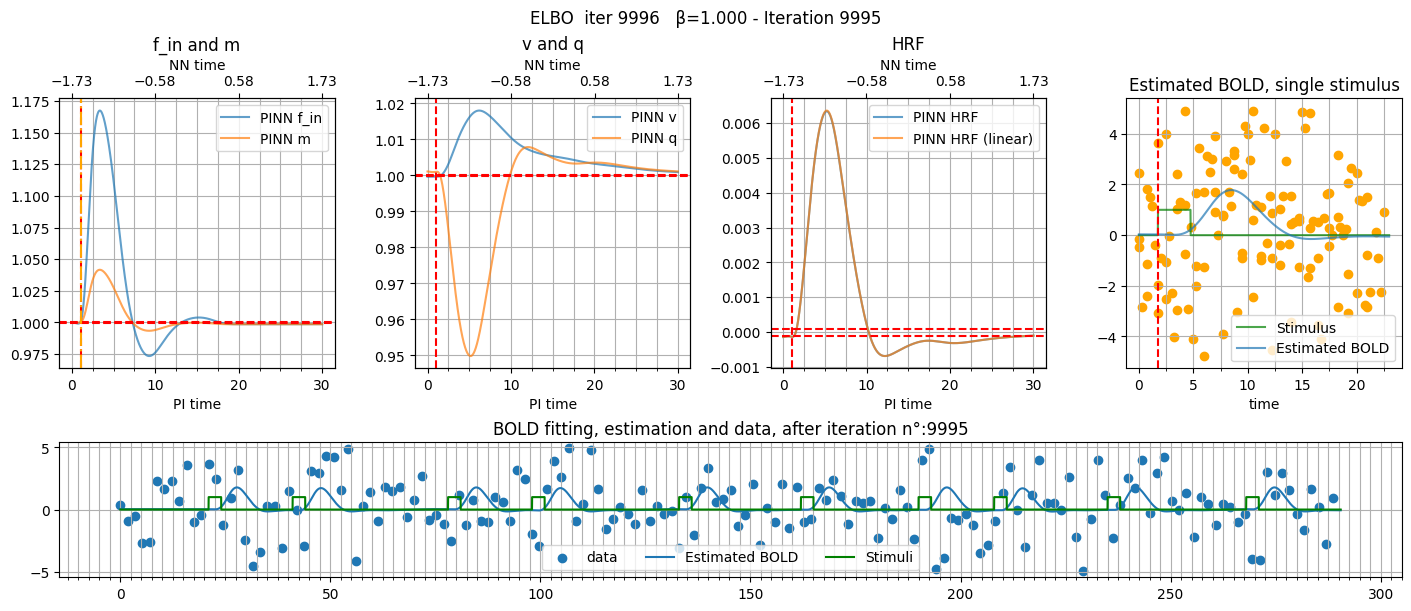

100%|██████████| 10000/10000 [02:21<00:00, 70.87it/s]


In [18]:
# Use the medium-noise realisation (index 1, σ=0.01)
sampled_noise_bold = tmp[0, ::sampling_rate]
tsnr_noisy = tSNR(tmp[:, ::sampling_rate])[0]

data_dict_noisy = {
    "TR": TR,
    "Sti_Onsets": Sti_Onsets,
    "Bold_Signal": sampled_noise_bold,
    "errorFn": nn.MSELoss(),
    "stim_length [seg]": sti_len,
    "stim_x_block": 1,
    "t0": 0,
}
num_iter = 10000
model_noisy = Multihead(random_weightsMatrix=True, dtype=torch.float32)
model_noisy.init_nn_params()

# optimizer_n = torch.optim.Adam(
#       list(model_noisy.parameters()) + list(posterior.parameters()),
#       lr=learning_rate,
#   )
optimizer_n  = torch.optim.Adam([
        {'params':model_noisy.parameters(), 'lr':learning_rate},
        {'params':posterior.parameters(), 'lr':learning_rate/100}
])

scheduler_n = optim.lr_scheduler.StepLR(
      optimizer_n, step_size=step_size, gamma=percent
  )

# Reset weights for noisy run
w_noisy = {k: [v[0]] for k, v in w_raw.items()}

loss_trace_noisy = elbo_train(
      model             = model_noisy,
      posterior         = posterior,
      base_balloon_params = base_balloon_params,   # mutated in-place
      data_params       = dict(data_dict_noisy),   # fresh copy — also mutated
      num_iter          = num_iter,
      beta_max          = 1.0,
      warmup_iters      = 1000,
      optimizer         = optimizer_n,
      scheduler         = scheduler_n,
      loss_weights      = w_noisy,
      domain            = domain,
      random            = False,
      every             = every,
  )

## 12  Visualise — noisy fit

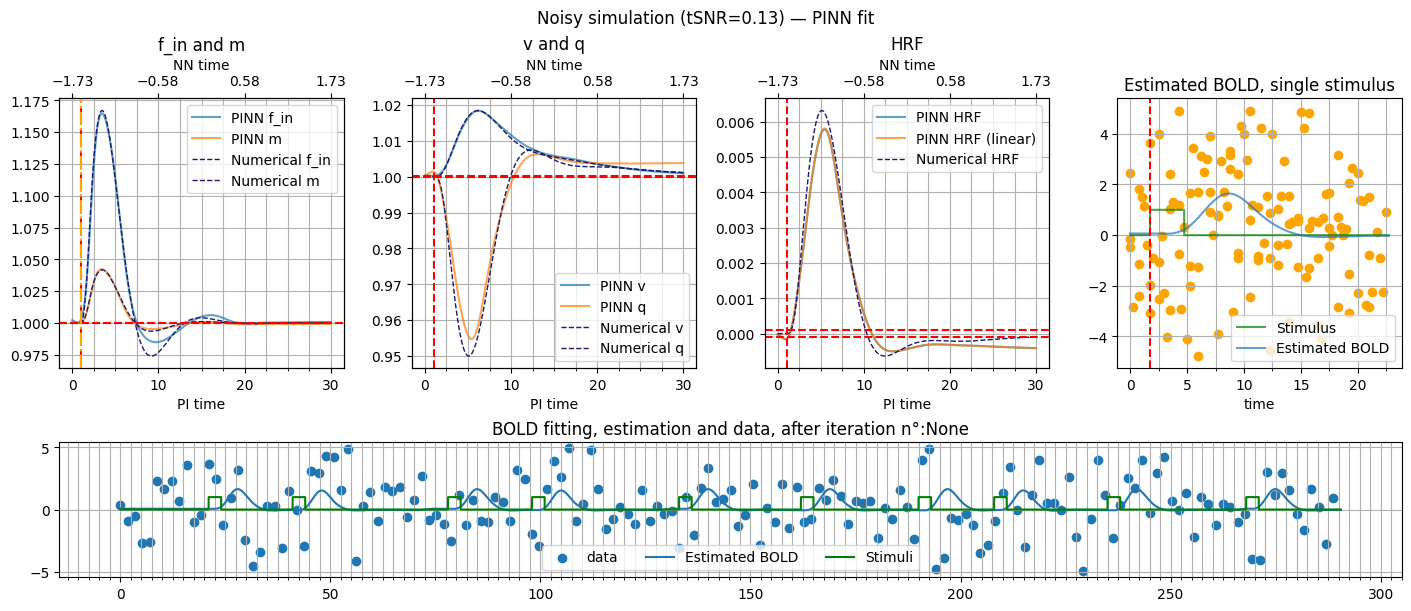

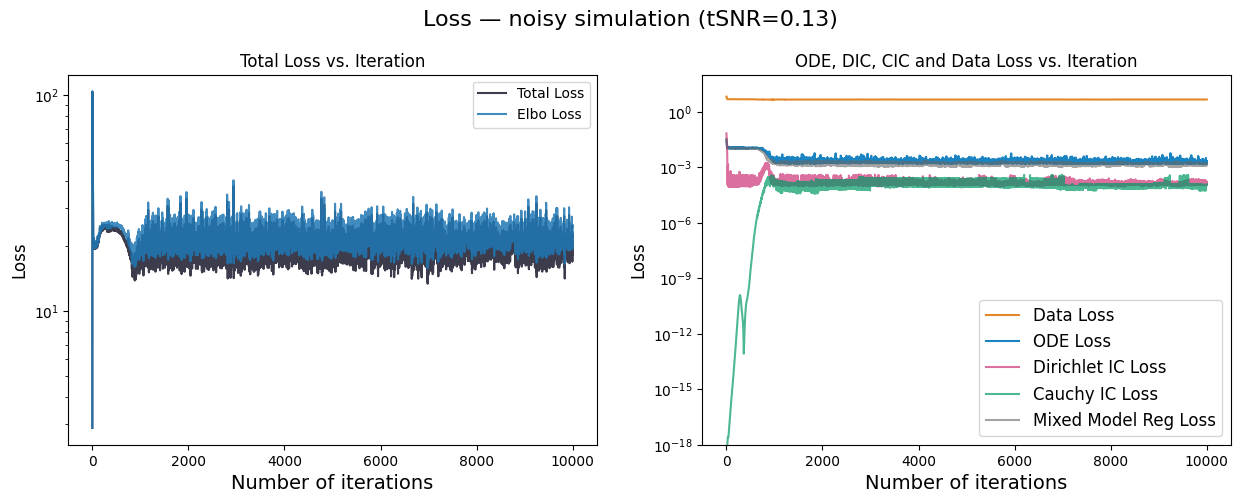

In [19]:
# load the best model checkpoint
best_model_cp = torch.load('./best_model.pth')
model_noisy.load_state_dict(best_model_cp['model_state_dict'])

plot_balloon_fitting(
    model=model_noisy,
    t_normalized=t_nn,
    domain=domain,
    stimulus=stimulus,
    title=f"Noisy simulation (tSNR={tsnr_noisy:.2f}) — PINN fit",
    numerical_solutions={"f": f_t, "m": m_t, "v": v_t, "q": q_t, "bold": num_balloon_hrf},
    data_params={
        "TR": TR,
        "Sti_Onsets": Sti_Onsets,
        "Bold_Signal": sampled_noise_bold,
        "Bold_data_time": num_bold_time[::sampling_rate],
        "stim_length [seg]": sti_len,
        "stimulus": stimulus,
        "stimulus_time": stimulus_time,
        "Overallstim": Overall_stims,
        "Overall_stim_time": stim_time,
    },
    first_non_zero_index=torch.argmax(Impulse) - 1,
    show_bold_signal=True,
)

tmpLoss = dict(list(loss_trace_noisy.items())[:5])
tmpLoss['total'] = loss_trace_noisy['pinn_total']
tmpLoss['elbo_total'] = loss_trace_noisy['elbo_total']
plot_trace(
    tmpLoss, title=f"Loss — noisy simulation (tSNR={tsnr_noisy:.2f})", step_size=step_size
)

In [20]:
best_model_cp['epoch']

979

In [21]:
posterior = BalloonPosterior(prior)
prior.print_summary()


  BalloonLatentPrior  —  K = 3 parameters
Parameter         Mode (physical)  Std (η-space)
------------------------------------------------
tau_0                      2.9477         0.3607
tau_m                     19.9477         0.3610
alpha                      0.4024         0.3608

Correlation matrix (unconstrained space):
                  tau_0    tau_m    alpha
  tau_0           1.000    0.036    0.015
  tau_m           0.036    1.000   -0.006
  alpha           0.015   -0.006    1.000

Fixed parameters (not sampled):
  epsilon_n      0.2
  kappa          0.6493506493506493
  gamma          0.4065040650406504



Posterior mode: {'tau_0': '2.9477', 'tau_m': '19.9477', 'alpha': '0.4024', 'epsilon_n': '0.2000', 'kappa': '0.6494', 'gamma': '0.4065'}


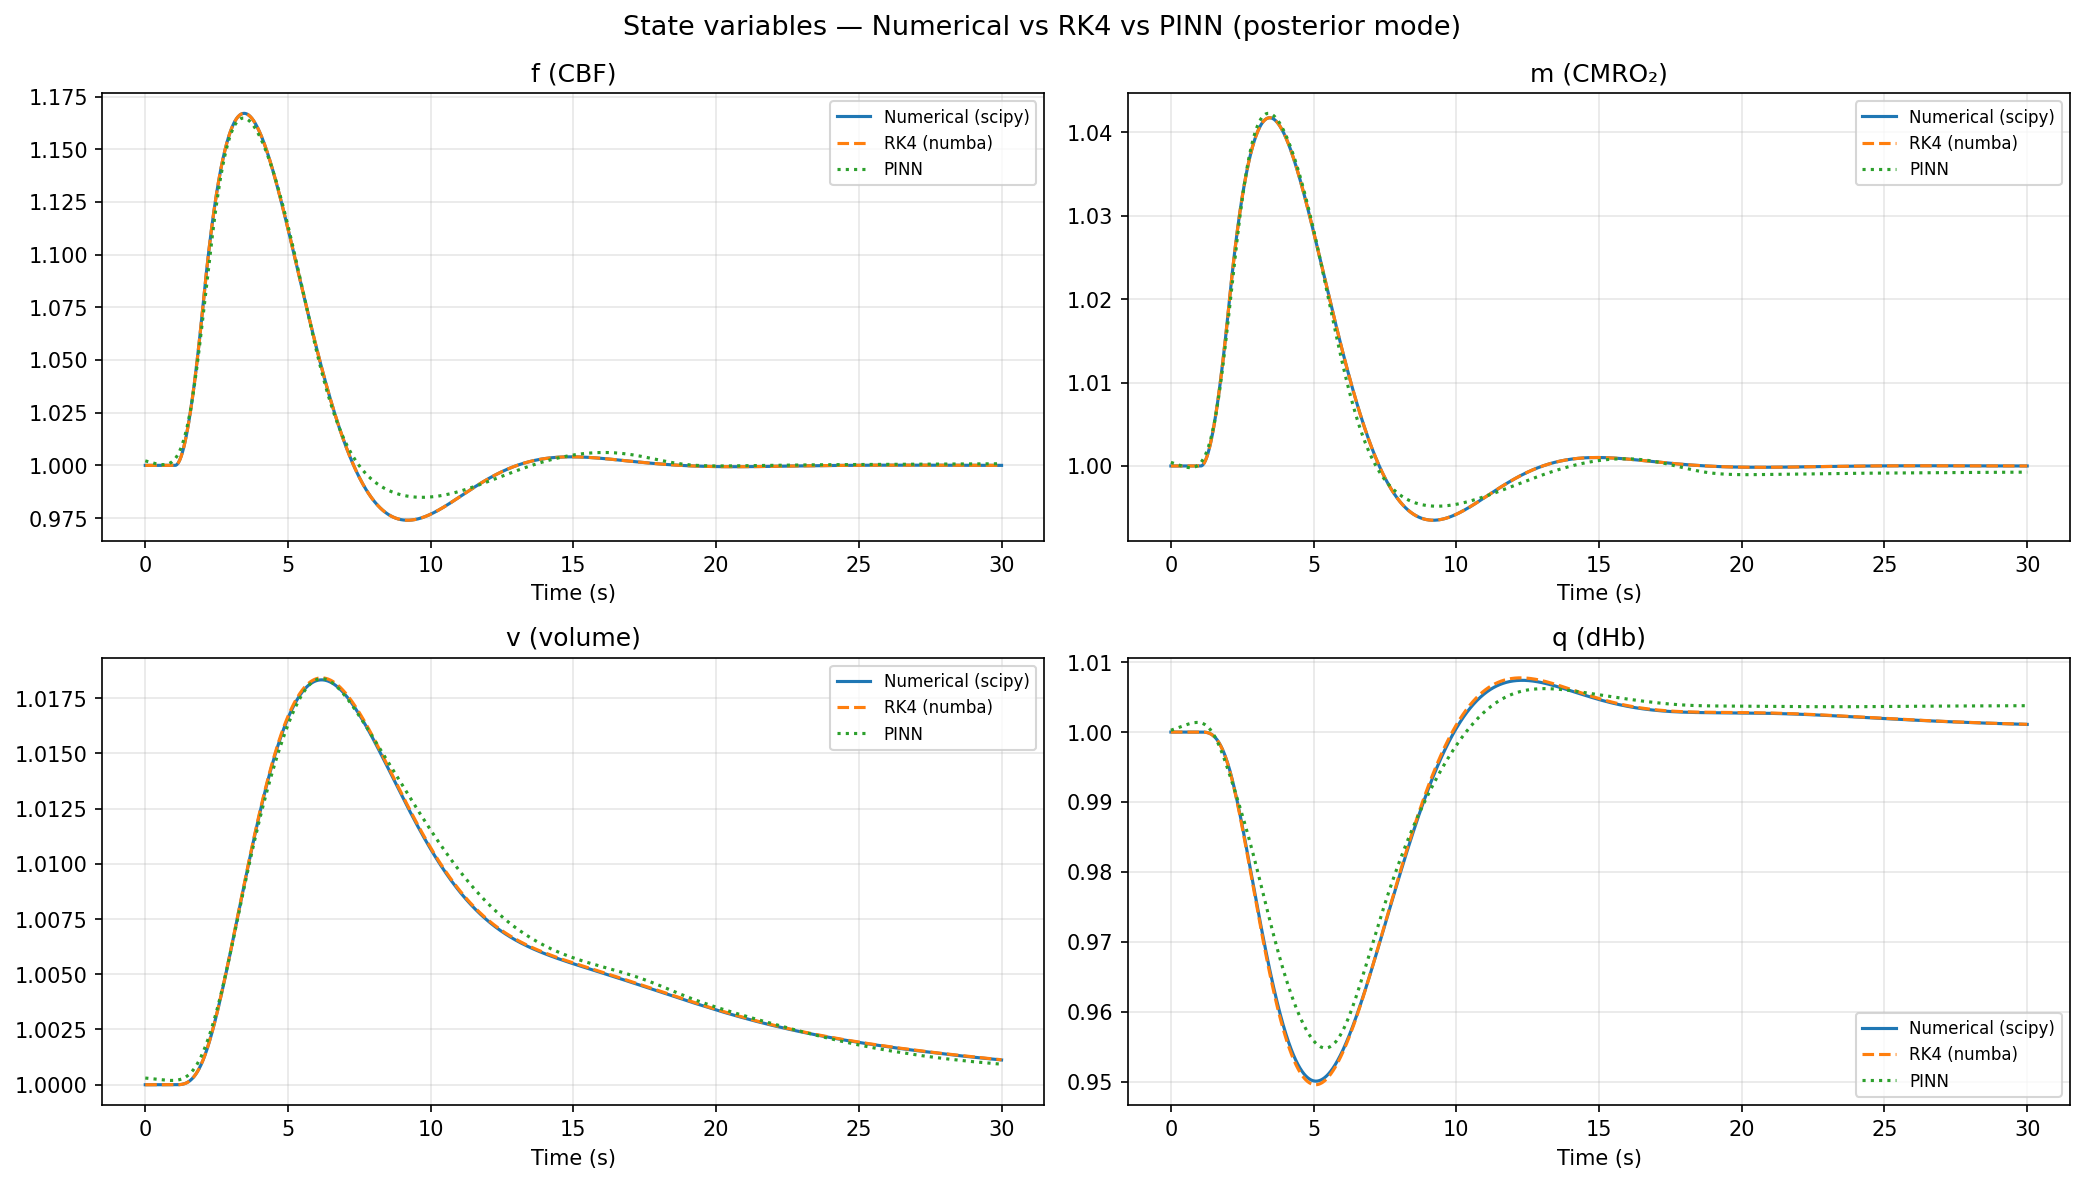

In [22]:
from balloonlib.physics import balloon_full_rk4_torch

# ── Posterior mode parameters (latent + fixed)
with torch.no_grad():
    physical_mode = {
        name: posterior.prior._transforms[i](posterior.mu_q[i]).item()
        for i, name in enumerate(posterior.prior.param_names)
    }
physical_mode.update(posterior.prior.fixed_params)
print("Posterior mode:", {k: f"{v:.4f}" for k, v in physical_mode.items()})

# ── RK4 solution at posterior mode
rk4_out = balloon_full_rk4_torch(
    I=Impulse,
    AmpI_f=physical_mode["epsilon_n"],
    AmpI_m=0.25 * physical_mode["epsilon_n"],  # cmro2_ratio
    kappa=physical_mode["kappa"],
    gamma=physical_mode["gamma"],
    tau_MTT=physical_mode["tau_0"],
    alpha=physical_mode["alpha"],
    tau_m=physical_mode["tau_m"],
)
rk4_np = tensor2np(rk4_out)  # (N, 4): columns [f, m, v, q]

# ── PINN model output
model_noisy.eval()
with torch.no_grad():
    _, _ = model_noisy(t_nn)

t_phys     = np.linspace(0, 30, Impulse.shape[0])
labels     = ["f (CBF)", "m (CMRO₂)", "v (volume)", "q (dHb)"]
pinn_vars  = [model_noisy.f, model_noisy.m, model_noisy.v, model_noisy.q]
num_vars   = [f_np, m_np, v_np, q_np]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=150)
for ax, label, pinn, num, col in zip(axes.flat, labels, pinn_vars, num_vars, range(4)):
    ax.plot(t_phys, num,               label="Numerical (scipy)", lw=1.5, color="tab:blue")
    ax.plot(t_phys, rk4_np[:, col],    label="RK4 (numba)",       lw=1.5, color="tab:orange", ls="--")
    ax.plot(t_phys, tensor2np(pinn),   label="PINN",              lw=1.5, color="tab:green",  ls=":")
    ax.set_title(label)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("State variables — Numerical vs RK4 vs PINN (posterior mode)", fontsize=13)
plt.tight_layout()
plt.show()

## Next steps

- **Real fMRI data**: replace `sampled_bold_test` with your normalised BOLD using `normFn()`
- **Adaptive reweighting**: call `loss_reweight_paranoid()` between training phases
- **Fourier features**: set `use_fourier=True` for improved high-frequency fitting
- **`BalloonExample.ipynb`**: deeper dive into the `balloonmodellib` numerical pipeline